In [1]:
# enable all interactive output to be 'printed'
# and disable scrolling so long output can be displayed w/o scroll bars

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
# methods for displaying and maintaining an image in jupyter frontend
from IPython.display import Image, display
# methods for displaying and maintaining an image in jupyter frontend
from IPython.display import Image, display

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
# train_dir = '/kaggle/input/asian-african-elephant/dataset/train'
# test_dir = '/kaggle/input/asian-african-elephant/dataset/test'

# Retrieve image data
extract_path = os.getcwd() + '\elephant_dataset'

train_dir = Path(extract_path) / "train"
test_dir = Path(extract_path) / "test"

# Print the contents
print("Training data folders:", os.listdir(train_dir))
print("Testing data folders:", os.listdir(test_dir))

# These directories should have two subfolders: 'asian' and 'african'

Training data folders: ['African', 'Asian']
Testing data folders: ['African', 'Asian']


In [6]:
def count_images(directory):
    for label in os.listdir(directory):
        folder = os.path.join(directory, label)
        count = len(os.listdir(folder))
        print(f"{label}: {count} images")

In [7]:
print("Training Set:")
count_images(train_dir)

print("\nTesting Set:")
count_images(test_dir)

Training Set:
African: 508 images
Asian: 502 images

Testing Set:
African: 50 images
Asian: 50 images


In [8]:
def plot_sample_images(class_name, directory, num_images=5):
    class_dir = os.path.join(directory, class_name)
    images = os.listdir(class_dir)[:num_images]

    plt.figure(figsize=(15, 5))
    for i, image_name in enumerate(images):
        img_path = os.path.join(class_dir, image_name)
        img = mpimg.imread(img_path)
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(class_name.replace('_', ' ').title())
        plt.axis('off')
    plt.show()

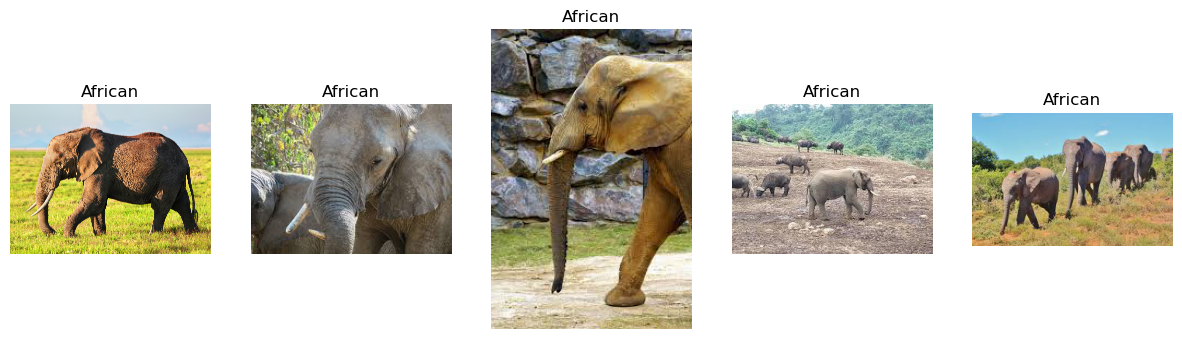

In [9]:
# Display African Elephant samples
plot_sample_images('African', train_dir)


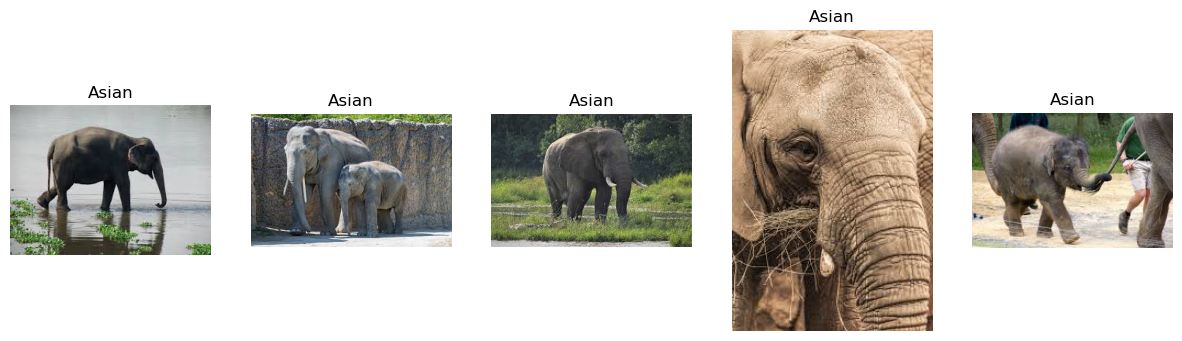

In [10]:
# Display African Elephant samples
plot_sample_images('Asian', train_dir)

In [11]:
IMG_SIZE = (224, 224)  # Common size for CNNs

In [12]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [13]:
test_datagen = ImageDataGenerator()
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary'  # Two classes: African or Asian
)

Found 1010 images belonging to 2 classes.


In [14]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 100 images belonging to 2 classes.


In [15]:
 
model = models.Sequential([
layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(224, 224, 3)),

  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(1 , activation = 'sigmoid')
])

In [16]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [17]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 56, 56, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       6,422,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,460,673 (24.65 MB)

 Trainable params: 6,460,673 (24.65 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# epochs is usually higher 50 but for reasons of time, leaving it at 15
history = model.fit(
    train_generator,
    epochs = 15,
    validation_data=test_generator
)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 152s 4s/step - accuracy: 0.5094 - loss: 0.7070 - val_accuracy: 0.5000 - val_loss: 28.2540
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.5418 - loss: 0.6828 - val_accuracy: 0.7000 - val_loss: 9.6329
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.6288 - loss: 0.6547 - val_accuracy: 0.7400 - val_loss: 17.7852
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.6005 - loss: 0.6655 - val_accuracy: 0.7200 - val_loss: 26.4247
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.6237 - loss: 0.6452 - val_accuracy: 0.7100 - val_loss: 34.5784
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.6098 - loss: 0.6454 - val_accuracy: 0.7300 - val_loss: 30.1208
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.6336 - loss: 0.6351 - val_accuracy: 0.7500 - val_loss: 20.6475
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.6620 - loss: 0.6332 - val_accuracy: 0.76

In [20]:
# Final training and validation metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

Final Training Accuracy: 0.6475
Final Validation Accuracy: 0.7600
Final Training Loss: 0.6267
Final Validation Loss: 23.5942


In [21]:
# Predict probabilities
pred_probs = model.predict(test_generator)

# Convert probabilities to class labels (0 or 1)
pred_classes = (pred_probs > 0.5).astype(int).reshape(-1)

# True labels from generator
true_classes = test_generator.classes

# Class labels mapping (optional, for report readability)
class_labels = list(test_generator.class_indices.keys())  # ['African', 'Asian']

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)

# Classification Report
report = classification_report(true_classes, pred_classes, target_names=class_labels)

print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step

Confusion Matrix:
 [[32 18]
 [ 6 44]]

Classification Report:
               precision    recall  f1-score   support

     African       0.84      0.64      0.73        50
       Asian       0.71      0.88      0.79        50

    accuracy                           0.76       100
   macro avg       0.78      0.76      0.76       100
weighted avg       0.78      0.76      0.76       100



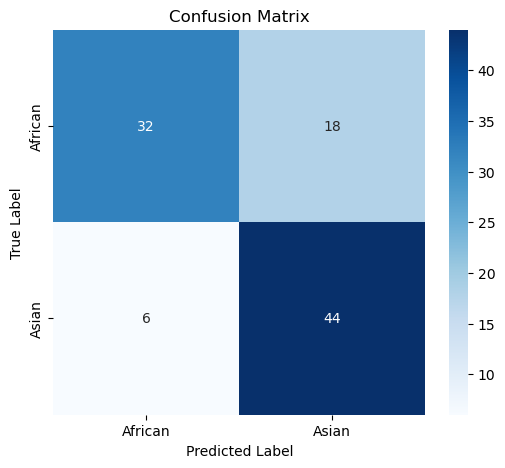

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show();
